# 01 — Baselines ResNet18

Este notebook define los dos baselines oficiales para comparar el resto de experimentos:

1. `ResNet18 frozen linear-probe baseline`: backbone ImageNet congelado + clasificador entrenable.
2. `ResNet18 fine-tuned + data augmentation`: backbone completo entrenable + mismas corrupciones de entrenamiento.

**Tres fases**:
1. _warmup_ del clasificador en datos limpios (3 ep)
2. _corrupt_ — train con corrupciones aleatorias p=0.7 (6 ep)
3. _joint_ — refinamiento con lr reducido (10 ep)

Activa `RUN_TRAINING = True` para entrenar los checkpoints que falten. Si está en `False`, solo se evalúan checkpoints existentes. Los resultados agregados se escriben en `out/baseline_summary.csv` y `out/baseline_curves.csv`.

In [7]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'dememte').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT)

repo root: /home/nakato/projects/Dememte


In [8]:
import json, shutil
from dataclasses import asdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dememte.config import BaselineConfig, resolve_data_dir
from dememte.data import build_loaders, seed_everything
from dememte.models import ResNetBaseline
from dememte.training import train_baseline_phased
from dememte.evaluation import evaluate_baseline_suite, signal_curve_rows_baseline
from dememte.io import save_checkpoint, load_checkpoint, write_json, write_csv, ensure_dir

RUN_TRAINING = True  # flip to True to train missing checkpoints

base_cfg = BaselineConfig()
base_cfg.data_dir = resolve_data_dir(base_cfg)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT = ensure_dir(ROOT / 'notebooks' / '01_baseline' / 'out')
LEGACY_FROZEN_CKPT = OUT / 'baseline_best.pt'

BASELINES = [
    {
        'id': 'resnet18_frozen_linear_probe',
        'label': 'ResNet18 frozen linear-probe baseline',
        'freeze_backbone': True,
        'train_corrupt_prob': 0.70,
        'legacy_ckpt': LEGACY_FROZEN_CKPT,
    },
    {
        'id': 'resnet18_finetuned_aug',
        'label': 'ResNet18 fine-tuned + data augmentation',
        'freeze_backbone': False,
        'train_corrupt_prob': 0.70,
        'legacy_ckpt': None,
    },
]

seed_everything(base_cfg.seed)
print(json.dumps(asdict(base_cfg), indent=2))

{
  "data_dir": "/home/nakato/projects/Dememte/experiments/data",
  "num_classes": 102,
  "batch_size": 16,
  "num_workers": 2,
  "device": "cuda",
  "val_ratio": 0.2,
  "split_seed": 42,
  "benchmark_protocol": "historical_trainval_resplit",
  "freeze_backbone": true,
  "backbone_lr": 0.0001,
  "lr_cls": 0.0001,
  "weight_decay": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 2,
  "early_stop_patience": 3,
  "early_stop_min_delta": 0.0001,
  "epochs_warmup": 3,
  "epochs_corrupt": 6,
  "epochs_joint": 10,
  "train_corrupt_prob": 0.7,
  "out_dir": "./out",
  "seed": 42
}


## Datos

In [9]:
tr_loader, va_loader, te_loader, meta = build_loaders(
    data_dir=base_cfg.data_dir,
    batch_size=base_cfg.batch_size,
    num_workers=base_cfg.num_workers,
    val_ratio=base_cfg.val_ratio,
    split_seed=base_cfg.split_seed,
    protocol=base_cfg.benchmark_protocol,
)
print(meta)

{'protocol': 'historical_trainval_resplit', 'split_seed': 42, 'train_size': 1632, 'val_size': 408, 'test_size': 6149}


## Configuración de baselines

In [10]:
for spec in BASELINES:
    cfg = BaselineConfig(freeze_backbone=spec['freeze_backbone'])
    cfg.data_dir = base_cfg.data_dir
    cfg.train_corrupt_prob = spec['train_corrupt_prob']
    spec['cfg'] = cfg
    spec['out_dir'] = ensure_dir(OUT / spec['id'])
    spec['ckpt'] = spec['out_dir'] / 'best.pt'
    print(f"{spec['id']}: {spec['label']} | freeze_backbone={cfg.freeze_backbone} | train_corrupt_prob={cfg.train_corrupt_prob} | ckpt={spec['ckpt']}")

resnet18_frozen_linear_probe: ResNet18 frozen linear-probe baseline | freeze_backbone=True | train_corrupt_prob=0.7 | ckpt=/home/nakato/projects/Dememte/notebooks/01_baseline/out/resnet18_frozen_linear_probe/best.pt
resnet18_finetuned_aug: ResNet18 fine-tuned + data augmentation | freeze_backbone=False | train_corrupt_prob=0.7 | ckpt=/home/nakato/projects/Dememte/notebooks/01_baseline/out/resnet18_finetuned_aug/best.pt


## Entrenamiento/carga + evaluación

In [11]:
all_summaries = []
all_curves = []

for spec in BASELINES:
    cfg = spec['cfg']
    ckpt = spec['ckpt']
    out_dir = spec['out_dir']
    seed_everything(cfg.seed)
    print(f"\n=== {spec['label']} ===")
    model = ResNetBaseline(num_classes=cfg.num_classes, freeze_backbone=cfg.freeze_backbone).to(device)
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'trainable params: {n_trainable:,} / {n_total:,}')

    ready = False
    if RUN_TRAINING:
        model, best_val = train_baseline_phased(model, tr_loader, va_loader, cfg, device)
        save_checkpoint(model, ckpt, extra={'best_val': best_val, 'baseline_id': spec['id'], 'label': spec['label'], 'config': asdict(cfg)})
        print(f'saved {ckpt} (best_val={best_val:.4f})')
        ready = True
    else:
        legacy = spec.get('legacy_ckpt')
        if not ckpt.exists() and legacy is not None and legacy.exists():
            print('seeding from legacy checkpoint:', legacy)
            shutil.copy(legacy, ckpt)
        if ckpt.exists():
            payload = load_checkpoint(model, ckpt, device=device, strict=True)
            print('loaded:', ckpt, '| best_val:', payload.get('best_val'))
            ready = True
        else:
            print(f"SKIP: checkpoint missing for {spec['id']}. Set RUN_TRAINING=True to train it.")

    if not ready:
        continue

    metrics = evaluate_baseline_suite(model, te_loader, device=device, return_predictions=True)
    clean_record = metrics.pop('clean_record')
    corrupt_records = metrics.pop('corruption_records')

    predictions = clean_record.pop('predictions', [])
    for rows in corrupt_records.values():
        for rec in rows:
            predictions.extend(rec.pop('predictions', []))

    summary = {k: v for k, v in metrics.items() if isinstance(v, (int, float))}
    summary.update({
        'baseline_id': spec['id'],
        'label': spec['label'],
        'freeze_backbone': cfg.freeze_backbone,
        'train_corrupt_prob': cfg.train_corrupt_prob,
        'trainable_params': n_trainable,
        'total_params': n_total,
        'checkpoint': str(ckpt),
        'protocol': meta['protocol'],
        'split_seed': meta['split_seed'],
    })
    curves = signal_curve_rows_baseline(spec['label'], clean_record, corrupt_records)
    for row in curves:
        row['baseline_id'] = spec['id']

    write_json(summary, out_dir / 'metrics.json')
    write_csv(predictions, out_dir / 'predictions.csv')
    write_csv(curves, out_dir / 'corrupt_curves.csv')
    all_summaries.append(summary)
    all_curves.extend(curves)

    if spec['id'] == 'resnet18_frozen_linear_probe':
        write_json(summary, OUT / 'metrics.json')
        write_csv(predictions, OUT / 'predictions.csv')
        write_csv(curves, OUT / 'corrupt_curves.csv')

write_json(all_summaries, OUT / 'baselines_metrics.json')
write_csv(all_summaries, OUT / 'baseline_summary.csv')
write_csv(all_curves, OUT / 'baseline_curves.csv')
pd.DataFrame(all_summaries).sort_values('corrupt_acc_avg', ascending=False) if all_summaries else pd.DataFrame()


=== ResNet18 frozen linear-probe baseline ===
trainable params: 52,326 / 11,228,838
[BASE-warmup 01] tr_loss=4.6956 tr_acc=0.0165 val_loss=4.4668 val_acc=0.0588
[BASE-warmup 02] tr_loss=4.3583 tr_acc=0.0637 val_loss=4.2238 val_acc=0.1225
[BASE-warmup 03] tr_loss=4.1084 tr_acc=0.1452 val_loss=3.9935 val_acc=0.2034
[BASE-corrupt 01] tr_loss=4.0350 tr_acc=0.1979 val_loss=3.9625 val_acc=0.2304
[BASE-corrupt 02] tr_loss=3.8664 tr_acc=0.2733 val_loss=3.9973 val_acc=0.1740
[BASE-corrupt 03] tr_loss=3.7048 tr_acc=0.3640 val_loss=3.8499 val_acc=0.2132
[BASE-corrupt 04] tr_loss=3.5630 tr_acc=0.4026 val_loss=3.6760 val_acc=0.2696
[BASE-corrupt 05] tr_loss=3.4287 tr_acc=0.4663 val_loss=3.5177 val_acc=0.2819
[BASE-corrupt 06] tr_loss=3.2291 tr_acc=0.5521 val_loss=3.3022 val_acc=0.4265
[BASE-joint 01] tr_loss=3.1979 tr_acc=0.5404 val_loss=3.6270 val_acc=0.2598
[BASE-joint 02] tr_loss=3.1119 tr_acc=0.5748 val_loss=3.2271 val_acc=0.4314
[BASE-joint 03] tr_loss=3.0000 tr_acc=0.6207 val_loss=3.2656 val

,clean_acc,corrupt_acc_avg,corrupt_acc_gaussian_noise,corrupt_acc_pixel_mask,corrupt_acc_cutout,corrupt_acc_blur,ece_clean,ece_corrupt_avg,nll_clean,nll_corrupt_avg,...,brier_corrupt_avg,baseline_id,label,freeze_backbone,train_corrupt_prob,trainable_params,total_params,checkpoint,protocol,split_seed
1,0.879167,0.578089,0.396162,0.306012,0.795360,0.814821,0.172045,0.167071,0.66441,1.961585,...,0.564503,resnet18_finetuned_aug,ResNet18 fine-tuned + data augmentation,False,0.7,11228838,11228838,/home/nakato/projects/Dememte/notebooks/01_bas...,historical_trainval_resplit,42
0,0.562043,0.291904,0.144034,0.112593,0.463978,0.447010,0.465952,0.225121,2.86154,3.553149,...,0.925640,resnet18_frozen_linear_probe,ResNet18 frozen linear-probe baseline,True,0.7,52326,11228838,/home/nakato/projects/Dememte/notebooks/01_bas...,historical_trainval_resplit,42


## Curvas comparativas de robustez

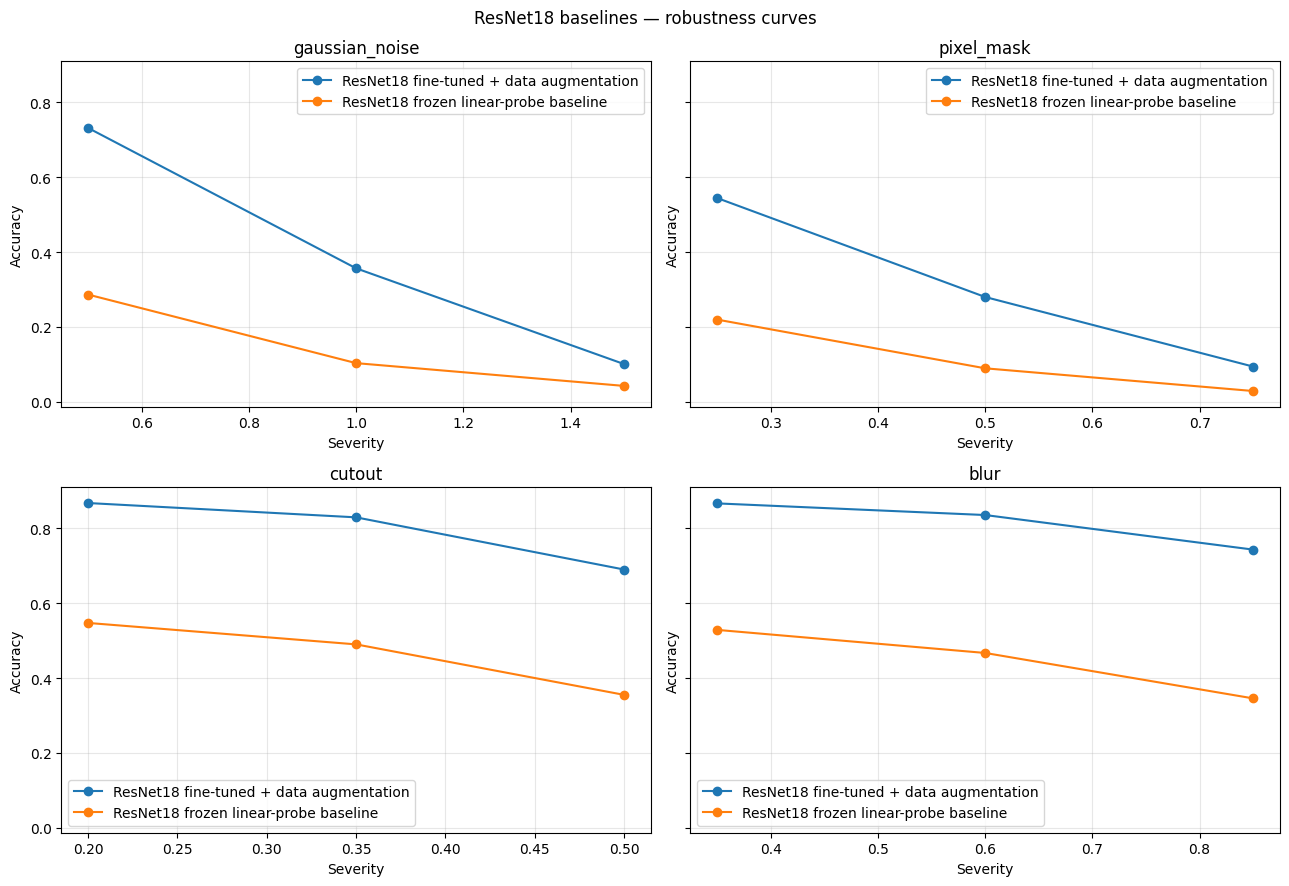

In [12]:
curves_path = OUT / 'baseline_curves.csv'
fig = None
if curves_path.exists() and curves_path.stat().st_size > 0:
    curves = pd.read_csv(curves_path)
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
    for ax, corr in zip(axes.flat, ['gaussian_noise', 'pixel_mask', 'cutout', 'blur']):
        for label, sub in curves[curves['corruption'] == corr].groupby('model'):
            ax.plot(sub['severity'], sub['acc'], marker='o', label=label)
        ax.set_title(corr)
        ax.set_xlabel('Severity')
        ax.set_ylabel('Accuracy')
        ax.grid(alpha=0.3)
        ax.legend()
    fig.suptitle('ResNet18 baselines — robustness curves')
    plt.tight_layout()
else:
    print('No baseline curves yet. Train or load at least one checkpoint first.')
ensure_dir(OUT / 'plots')
if fig is not None:
    fig.savefig(OUT / 'plots' / 'baseline_robustness_curves.png', dpi=120, bbox_inches='tight')
    plt.show()